In [105]:
import math
import numpy as np
import matplotlib.pyplot as plt
import re
%matplotlib inline

In [106]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for each value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')

        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connection n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
        
    return dot

In [107]:
class Value:
  def __init__(self, data, _children=(), _op='', label=""):
    self.data = data
    self.grad = 0.0
    self._backward = lambda : None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def _construct_op(self, other=None, op=None):
    if (op == "**"):
      assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    elif (other is not None):
      other = other if isinstance(other, Value) else Value(other)

    if op == "+":
      out = Value(self.data + other.data, (self, other), '+')
    elif op == "*":
      out = Value(self.data * other.data, (self, other), '*')
    elif op == "**":
      out = Value(self.data ** other, (self,), f'**{other}')
    elif op == "exp":
      out = Value(math.exp(self.data), (self, ), 'exp')
    elif op == "tanh":
      x = self.data
      t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
      out = Value(t, (self, ), 'tanh')

    def _backward():
      if op == "+":
        self.grad += 1.0 * out.grad
        other.grad += 1.0 * out.grad
      elif op == "*":
        self.grad += other.data * out.grad
        other.grad += self.data * out.grad
      elif op == "**":
        self.grad = other * (self.data**(other - 1)) * out.grad
      elif op == "exp":
        self.grad += out.data * out.grad
      elif op == "tanh":
        self.grad += (1 - t**2) * out.grad

    out._backward = _backward
    return out

  def __add__(self, other):
    return self._construct_op(other, "+")
  def __radd__(self, other):
    return self + other

  def __sub__(self, other):
    return self + (-other)
  def __rsub__(self, other):
    return self - other
  
  def __neg__(self):
    return self * -1.0

  def __mul__(self, other):
    return self._construct_op(other, "*")
  def __rmul__(self, other):
    return self * other
  
  def __pow__(self, other):
    return self._construct_op(other, "**")
  
  def __truediv__(self, other):
    return self * other**-1
  
  def exp(self):
    return self._construct_op(op="exp")
  def tanh(self):
    return self._construct_op(op="tanh")

  def backward(self):
    self.grad = 1.0
    topo = []
    visited = set()

    def build_topo(root):
      if root not in visited:
        visited.add(root)
        for child in root._prev:
          build_topo(child)
        topo.append(root)
    build_topo(self)

    for n in reversed(topo):
      n._backward()


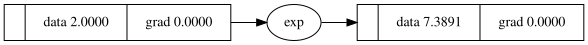

In [108]:
a = Value(2.0)
b = Value(4.0)
c = a.exp()
draw_dot(c)

In [109]:
# inputs x1,x2
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

# weights w1,w2
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

# bias of the neuron
b = Value(6.8813735870195432, label="b")

# x1*x2 + w1*w2 + b
x1w1 = x1*w1; x1w1.label = "x1*w1"
x2w2 = x2*w2; x2w2.label = "x2*w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1*w1 + w1*w2"
n = x1w1x2w2 + b; n.label = "n"
o = n.tanh(); o.label = "o"

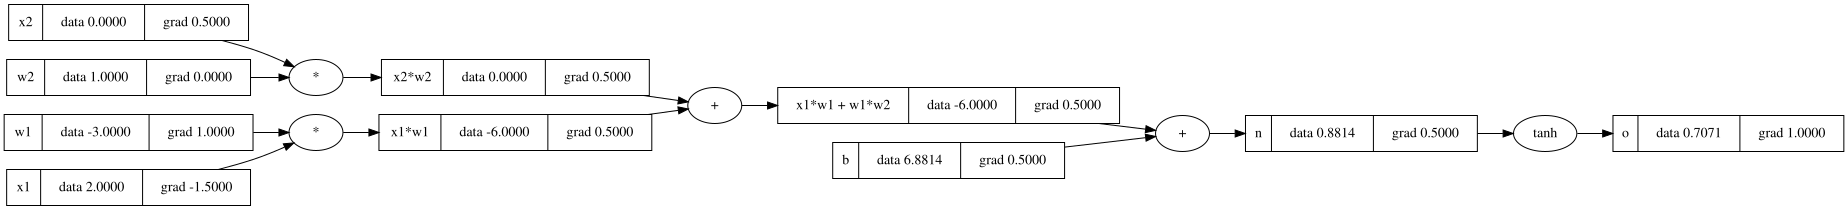

In [110]:

o.backward()
draw_dot(o)

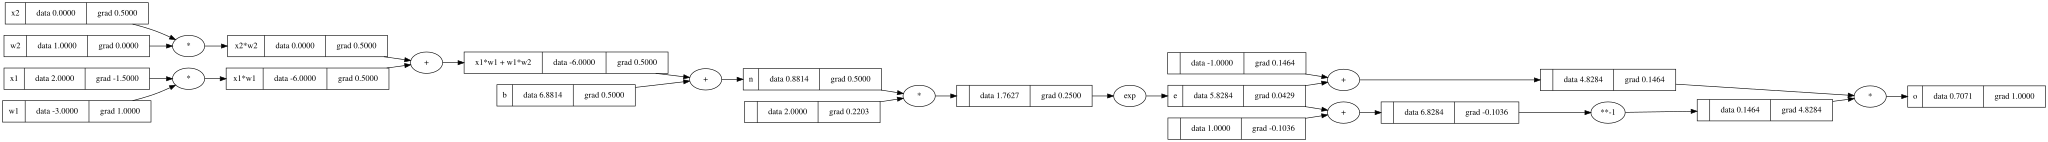

In [111]:
# inputs x1,x2
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

# weights w1,w2
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

# bias of the neuron
b = Value(6.8813735870195432, label="b")

# x1*x2 + w1*w2 + b
x1w1 = x1*w1; x1w1.label = "x1*w1"
x2w2 = x2*w2; x2w2.label = "x2*w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1*w1 + w1*w2"
n = x1w1x2w2 + b; n.label = "n"
# ----------------------
e = (2 * n).exp(); e.label = "e"
o = (e - 1) / (e + 1); o.label = "o"
o.backward()
draw_dot(o)

In [112]:
import random

In [113]:
class Neuron:
  def __init__(self, nin):
    self.w = [(Value(random.uniform(-1, 1))) for _ in range(nin)]
    self.b = Value(random.uniform(-1, 1))

  def __call__(self, x):
    act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out
  
  def parameters(self):
    return self.w + [self.b]

class Layer:
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs
  
  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i + 1]) for i in range(len(nouts))]
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [ ]:
x = [2.0, 3.0, 7.0]
m = MLP(3, [4, 4, 1])
res = m(x)

[Value(data=-0.2864253304829967),
 Value(data=0.6126423746008871),
 Value(data=0.05401772392721149),
 Value(data=0.1920523483864276),
 Value(data=-0.11638651967564195),
 Value(data=0.3391879078960034),
 Value(data=0.3038201884651084),
 Value(data=-0.6645192578654207),
 Value(data=0.23548203470911377),
 Value(data=-0.8694249908113842),
 Value(data=-0.08192164230119725),
 Value(data=0.554615913489493),
 Value(data=-0.6730817823055997),
 Value(data=0.2708079502254308),
 Value(data=-0.5329409353253085),
 Value(data=0.08808699206893666),
 Value(data=-0.6544112893875607),
 Value(data=-0.5379531248810037),
 Value(data=0.4248594982466207),
 Value(data=0.4756267940862753),
 Value(data=0.9054640431697185),
 Value(data=0.997753404899667),
 Value(data=-0.4282377374910833),
 Value(data=-0.4523598639263111),
 Value(data=0.11088069645225396),
 Value(data=-0.22115296059525424),
 Value(data=-0.5605596431751565),
 Value(data=-0.8406099628489323),
 Value(data=0.6285533382919355),
 Value(data=0.0414280569

In [115]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets
ypred = [m(x) for x in xs]
ypred

[Value(data=0.9606528358699694),
 Value(data=-0.17209776172706692),
 Value(data=0.6942402405329535),
 Value(data=0.9557657654077143)]

In [116]:
loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)])

In [117]:
loss.backward()

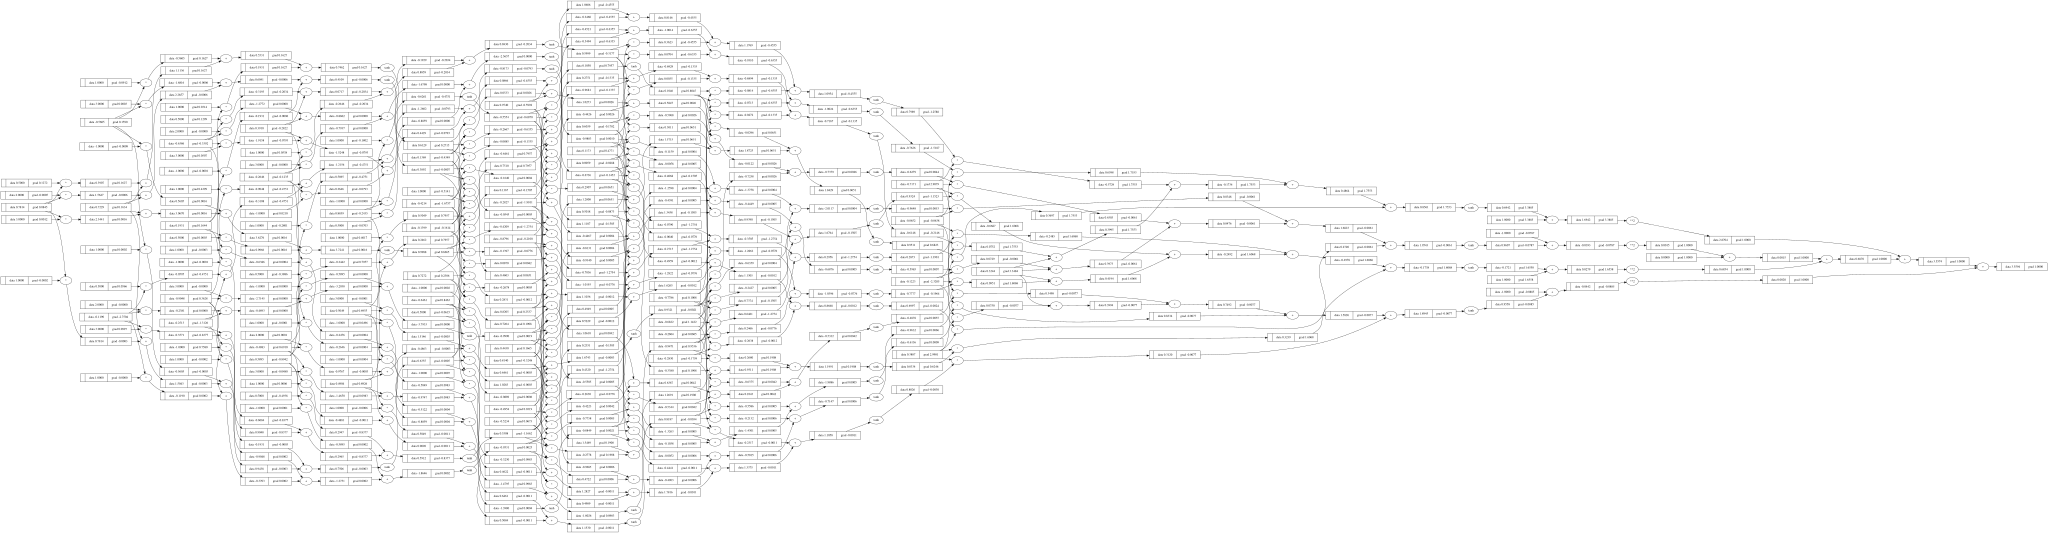

In [118]:
draw_dot(loss)